# 복사에 대한 간략한 개요

이 노트북은 Albany 대학교의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/) 교수가 저술한 [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

## 1. 방출 온도 및 기온 감률

행성 에너지 균형은 모든 기후 모델링의 기초입니다. 지금까지 우리는 이를 전 지구 평균 예산(budget)을 통해 표현했습니다.

$$C \frac{d T_s}{dt} = (1-\alpha) Q - OLR$$

그리고 우리는 OLR(장파복사 방출량)을 방출 온도 $T_e$로 정의하여 나타냈습니다.

$$ OLR = \sigma T_e^4 $$

관측된 행성 에너지 수지(planetary energy budget) 값을 활용하여, 우리는 $T_e = 255$ K 임을 확인했습니다.

따라서 행성의 방출 온도(emission temperature)는 평균 표면 온도(mean surface temperature, 288 K)보다 약 33 K 더 낮습니다.

### 대기 중 어느 고도에서 $T = T_e = 255$ K를 찾을 수 있을까요?

이는 약 -18ºC에 해당합니다.

NCEP 재분석 자료에서 **전 지구적 연평균 관측 기온**을 그려봅시다.

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [7]:
## The NOAA ESRL server is shutdown! January 2019
#ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis.derived/"
#time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
#ncep_air = xr.open_dataset( ncep_url + "pressure/air.mon.1981-2010.ltm.nc",
#                          decode_times=time_coder)

# Install missing xarray backends if not already installed
import subprocess
import sys

try:
    import netCDF4
    import pydap
except ImportError:
    print("Installing netCDF4 and pydap...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "netCDF4", "pydap"])
    print("Installation complete. Please rerun the cell.")

url = 'http://apdrc.soest.hawaii.edu:80/dods/public_data/Reanalysis_Data/NCEP/NCEP/clima/pressure/air'
air = xr.open_dataset(url)
## The name of the vertical axis is different than the NOAA ESRL version..
ncep_air = air.rename({'lev': 'level'})
ncep_air

/usr/local/lib/python3.12/dist-packages/xarray/coding/times.py:215: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/tmp/ipykernel_3390/2360346507.py:20: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  air = xr.open_dataset(url)


<xarray.Dataset> Size: 17MB
Dimensions:         (time: 12, level: 17, lat: 73, lon: 144)
Coordinates:
  * time            (time) object 96B 0001-01-01 00:00:00 ... 0001-12-01 00:0...
  * level           (level) float64 136B 1e+03 925.0 850.0 ... 30.0 20.0 10.0
  * lat             (lat) float64 584B -90.0 -87.5 -85.0 ... 85.0 87.5 90.0
  * lon             (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
Data variables:
    air             (time, level, lat, lon) float32 9MB ...
    valid_yr_count  (time, level, lat, lon) float32 9MB ...
Attributes:
    title:          NMC reanalysis atlas
    Conventions:    COARDS\nGrADS
    dataType:       Grid
    documentation:  http://apdrc.soest.hawaii.edu/datadoc/ncep_clima.php
    history:        Mon Apr 20 03:24:42 HST 2026 : imported by GrADS Data Ser...

In [8]:
#  Take global, annual average and convert to Kelvin
coslat = np.cos(np.deg2rad(ncep_air.lat))
weight = coslat / coslat.mean(dim='lat')
Tglobal = (ncep_air.air * weight).mean(dim=('lat','lon','time'))
Tglobal

<xarray.DataArray (level: 17)> Size: 136B
array([ 15.17908417,  11.20700336,   7.83832797,   0.21994171,
        -6.448343  , -14.88884551, -25.57046941, -39.36968899,
       -46.79791277, -53.65224034, -60.5635572 , -67.00605444,
       -65.5329328 , -61.48664304, -55.85358625, -51.59394965,
       -43.21998609])
Coordinates:
  * level    (level) float64 136B 1e+03 925.0 850.0 700.0 ... 30.0 20.0 10.0
Attributes:
    grads_dim:      y
    grads_mapping:  linear
    grads_size:     73
    units:          degrees_north
    minimum:        -90.0
    maximum:        90.0
    resolution:     2.5

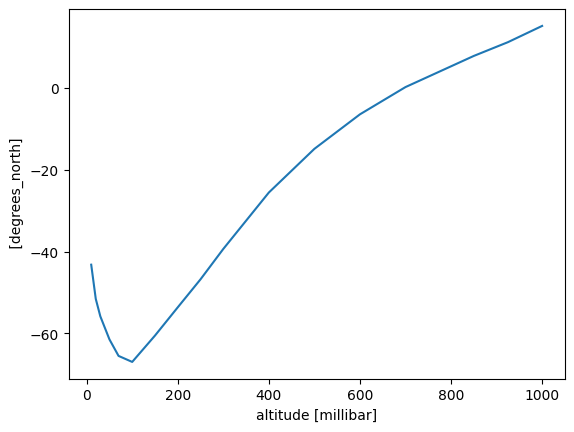

In [9]:
#  a "quick and dirty" visualization of the data
Tglobal.plot()

더 나은 플롯(plot)을 만들어 봅시다.

여기서는 `metpy`라는 패키지를 사용하여 기상학자들에게 더 익숙한 방식인 소위 *skew-T* 플롯(plot) 형태로 이 온도 프로파일(temperature profile)을 자동으로 그릴 것입니다.

In [14]:
# Install metpy if not already installed
import subprocess
import sys

try:
    from metpy.plots import SkewT
except ImportError:
    print("Installing metpy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "metpy"])
    print("Installation complete. Please rerun the cell.")
    from metpy.plots import SkewT

Text(0.5, 1.0, 'Global, annual mean sounding from NCEP Reanalysis')

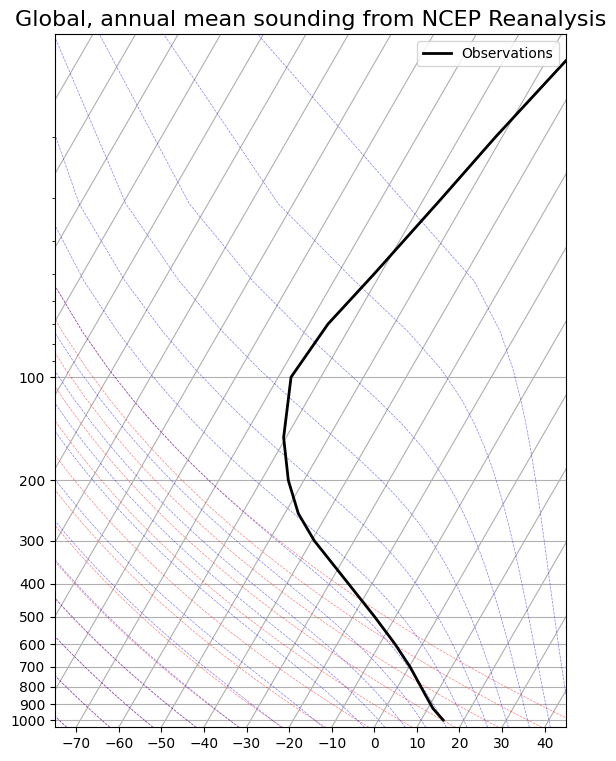

In [15]:
fig = plt.figure(figsize=(9, 9))
skew = SkewT(fig, rotation=30)
skew.plot(Tglobal.level, Tglobal, color='black', linestyle='-', linewidth=2, label='Observations')
skew.ax.set_ylim(1050, 10)
skew.ax.set_xlim(-75, 45)
# Add the relevant special lines
skew.plot_dry_adiabats(linewidth=0.5)
skew.plot_moist_adiabats(linewidth=0.5)
#skew.plot_mixing_lines()
skew.ax.legend()
skew.ax.set_title('Global, annual mean sounding from NCEP Reanalysis',
             fontsize = 16)

우리가 계속 언급했듯이, 전 지구 평균 지표면 온도(surface temperature)는 실제로 약 288 K 또는 15ºC입니다.

그렇다면 온도 $T_e=255$ K 또는 -18ºC는 어디에서 찾을 수 있을까요?

실제로는 중층 대류권(mid-troposphere), 즉 약 500 헥토파스칼(hPa) 또는 약 5 km 높이에서 찾을 수 있습니다.

우리는 외향 장파 복사(outgoing longwave radiation)의 대부분이 실제로 지표면에서 훨씬 위쪽에서 기원한다는 것을 추론할 수 있습니다.

우리가 관측한 지구 에너지 수지 다이어그램을 상기해보면, 총 239 W m$^{-2}$의 장파복사에너지(OLR)가 대기와 구름에 의해 방출되는데, 이 중 217 W m$^{-2}$는 대기와 구름에서 나오며, 지표면에서 직접 방출되는 양은 단 22 W m$^{-2}$에 불과하다는 것을 알 수 있습니다.

이는 **온실 효과** 때문이다.

지금까지 우리는 에너지 균형 모델에서 온실 효과를 매우 인위적인 방식으로 다루어 왔습니다. 이는 단순히 다음을 가정함으로써 이루어졌습니다.

$$ \text{OLR} = \tau \sigma T_s^4 $$

즉, OLR(장파복사 방출량)은 지구가 표면 온도(surface temperature)에서 흑체(blackbody)처럼 방출할 때 가질 값으로부터 상수 인자(constant factor)만큼 감소한다는 것입니다.

이제 우리는 복사 전달 과정(radiative transfer process)이 대기 중에서 실제로 어떻게 발생하는지, 그리고 이를 어떻게 모델링할지에 대해 좀 더 깊이 생각해 볼 때입니다.

## 2. 태양 복사 (Solar Radiation)

태양 복사 스펙트럼을 그래프로 그려봅시다.

파이썬(Python) 관련 자세한 내용은 코드 블록을 클릭하여 확장하거나 (또는 노트북에서 코드를 확인하세요).

In [17]:
# Install climlab if not already installed
import subprocess
import sys

try:
    from climlab.utils.thermo import Planck_wavelength
except ImportError:
    print("Installing climlab...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "climlab"])
    print("Installation complete. Please rerun the cell.")
    from climlab.utils.thermo import Planck_wavelength

Installing climlab...
Installation complete. Please rerun the cell.


/usr/local/lib/python3.12/dist-packages/climlab/radiation/cam3.py:45: UserWarning: Cannot import and initialize compiled Fortran extension, CAM3 module will not be functional.
  warnings.warn('Cannot import and initialize compiled Fortran extension, CAM3 module will not be functional.')
/usr/local/lib/python3.12/dist-packages/climlab/radiation/rrtm/rrtmg_lw.py:18: UserWarning: Cannot import and initialize compiled Fortran extension, RRTMG_LW module will not be functional.
  warnings.warn('Cannot import and initialize compiled Fortran extension, RRTMG_LW module will not be functional.')
/usr/local/lib/python3.12/dist-packages/climlab/radiation/rrtm/rrtmg_sw.py:19: UserWarning: Cannot import and initialize compiled Fortran extension, RRTMG_SW module will not be functional.
  warnings.warn('Cannot import and initialize compiled Fortran extension, RRTMG_SW module will not be functional.')
/usr/local/lib/python3.12/dist-packages/climlab/convection/emanuel_convection.py:12: UserWarning: Cann

In [19]:
# approximate emission temperature of the sun in Kelvin
Tsun = 5780.
# boundaries of visible region in nanometers
UVbound = 390.
IRbound = 700.
#  array of wavelengths
wavelength_nm = np.linspace(10., 3500., 400)
to_meters = 1E-9  # conversion factor

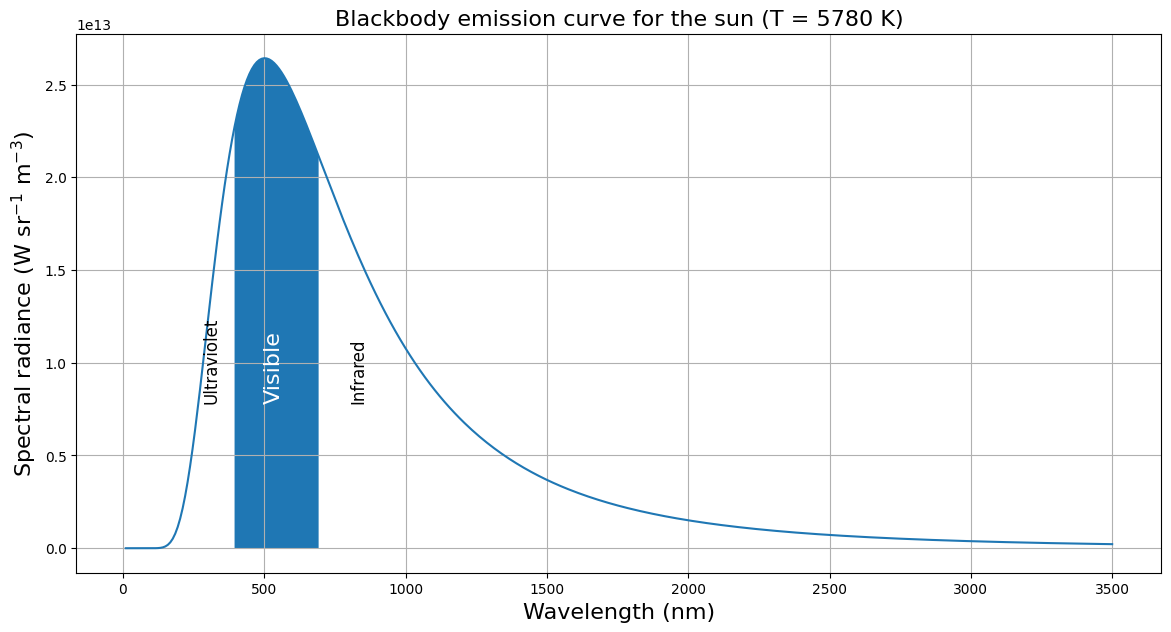

In [20]:
label_size = 16
fig, ax = plt.subplots(figsize=(14,7))
ax.plot(wavelength_nm,
         Planck_wavelength(wavelength_nm * to_meters, Tsun))
ax.grid()
ax.set_xlabel('Wavelength (nm)', fontsize=label_size)
ax.set_ylabel('Spectral radiance (W sr$^{-1}$ m$^{-3}$)', fontsize=label_size)
#  Mask out points outside of this range
wavelength_vis = np.ma.masked_outside(wavelength_nm, UVbound, IRbound)
#  Shade the visible region
ax.fill_between(wavelength_vis, Planck_wavelength(wavelength_vis * to_meters, Tsun))
title = 'Blackbody emission curve for the sun (T = {:.0f} K)'.format(Tsun)
ax.set_title(title, fontsize=label_size);
ax.text(280, 0.8E13, 'Ultraviolet', rotation='vertical', fontsize=12)
ax.text(500, 0.8E13, 'Visible', rotation='vertical', fontsize=16, color='w')
ax.text(800, 0.8E13, 'Infrared', rotation='vertical', fontsize=12);

- 스펙트럼은 가시광선 영역에서 정점에 이릅니다.
- 이 파장대에서 대부분의 에너지가 방출됩니다.
- 우리 눈이 이 파장대에 민감하게 반응하는 것은 우연이 아닙니다!
- 더 긴 파장은 “적외선(infrared)”이라 불리고, 더 짧은 파장은 “자외선(ultraviolet)”이라 불립니다.

스펙트럼의 형태는 복사(radiative) 방출의 근본적인 특징입니다.
(불 속에서 타는 석탄의 색깔을 생각해 보세요 – 더 차가울수록 = 빨간색, 더 뜨거울수록 = 흰색)

이론과 실험에 따르면, 방출되는 복사(선)의 총 플럭스와 최대 방출 파장 모두 오직 해당 원천(source)의 온도에만 의존합니다!

이론적인 스펙트럼은 막스 플랑크에 의해 도출되었으며, 따라서 "플랑크 스펙트럼"(또는 단순히 흑체 복사 스펙트럼)으로 알려져 있습니다.

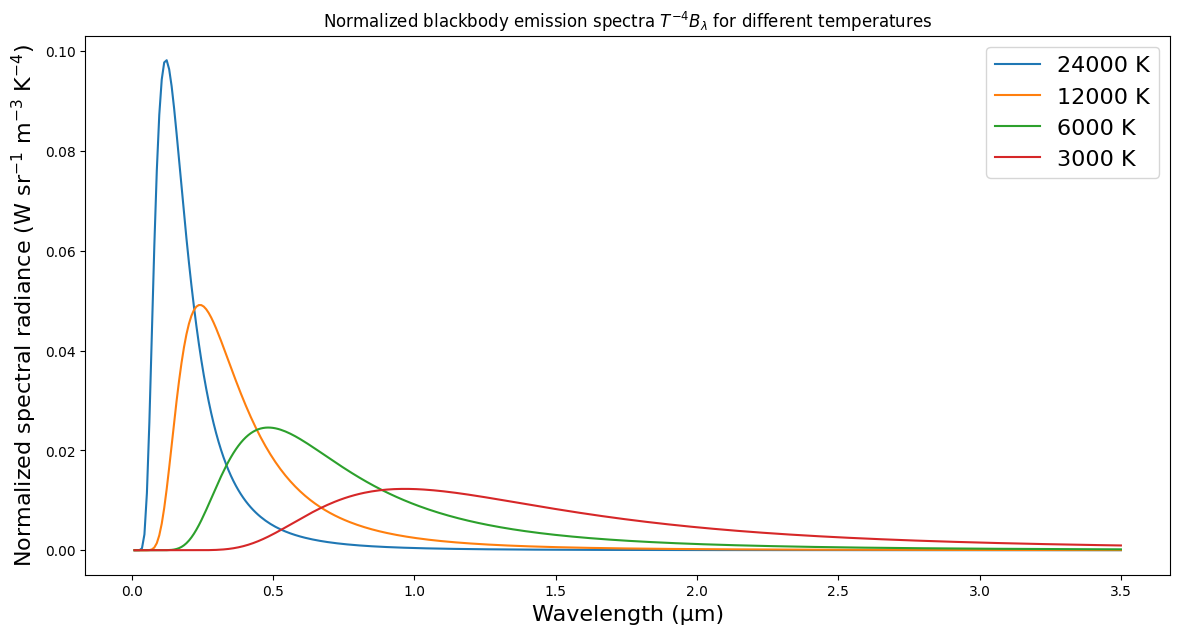

In [21]:
fig, ax = plt.subplots(figsize=(14,7))
wavelength_um = wavelength_nm / 1000
for T in [24000,12000,6000,3000]:
    ax.plot(wavelength_um,
         (Planck_wavelength(wavelength_nm * to_meters, T) / T**4),
           label=str(T) + ' K')
ax.legend(fontsize=label_size)
ax.set_xlabel(r'Wavelength (μm)', fontsize=label_size)
ax.set_ylabel(r'Normalized spectral radiance (W sr$^{-1}$ m$^{-3}$ K$^{-4}$)', fontsize=label_size)
ax.set_title(r"Normalized blackbody emission spectra $T^{-4} B_{\lambda}$ for different temperatures");

온도가 낮을 때에서 높아질 때:

- 총 방출량(emission)은 증가합니다.
- 최대 방출량(emission)은 더 짧은 파장(wavelength)에서 발생합니다.

이러한 **곡선들을 모든 파장(wavelength)에 대해 적분(integral)하면** 우리가 흔히 접하는 $\sigma T^4$ 값을 얻게 됩니다.

수학적으로는 다음이 밝혀졌습니다.

$$ λ_{max} T = \text{constant} $$

(빈의 변위 법칙으로 알려져 있습니다.)

관측된 태양 방출(emission)을 흑체 곡선에 맞춰 분석함으로써, 태양의 방출 온도(emission temperature)가 약 6000K임을 추론할 수 있습니다.

이를 바탕으로, 태양 스펙트럼이 0.6 마이크로미터에서 최대값을 갖는다는 점을 고려하면, 최대 지표 복사(terrestrial radiation)의 파장을 다음과 같이 계산할 수 있습니다.

$$ λ_{max}^{Earth} = 0.6 ~ \mu m \frac{6000}{255} = 14 ~ \mu m $$

이는 스펙트럼의 원적외선(far-infrared) 영역에 해당합니다.

## 3. 지구 복사 및 흡수 스펙트럼

### 지구 파장 대 태양 파장

이제 태양과 지구의 정규화된 흑체 곡선을 살펴보겠습니다.

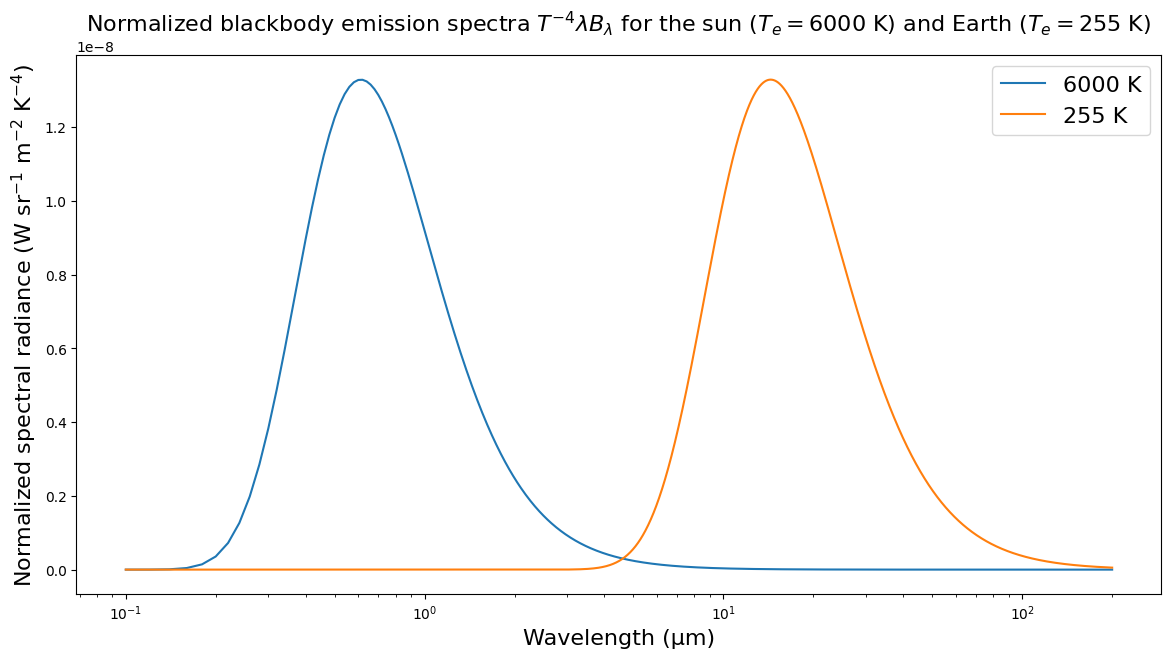

In [22]:
fig, ax = plt.subplots(figsize=(14,7))
wavelength_um = np.linspace(0.1, 200, 10000)
wavelength_meters = wavelength_um / 1E6

for T in [6000, 255]:
    ax.semilogx(wavelength_um,
         (Planck_wavelength(wavelength_meters, T) / T**4 * wavelength_meters),
           label=str(T) + ' K')
ax.legend(fontsize=label_size)
ax.set_xlabel(r'Wavelength (μm)', fontsize=label_size)
ax.set_ylabel(r'Normalized spectral radiance (W sr$^{-1}$ m$^{-2}$ K$^{-4}$)', fontsize=label_size)
ax.set_title(r"Normalized blackbody emission spectra $T^{-4} \lambda B_{\lambda}$ for the sun ($T_e = 6000$ K) and Earth ($T_e = 255$ K)",
            fontsize=label_size);

두 스펙트럼 사이에는 사실상 거의 겹치는 부분이 없습니다.

**이것이 우리가 태양의 "단파(shortwave)" 복사와 지구의 "장파(longwave)" 복사를 두 가지 별개의 현상으로 논의할 수 있는 근본적인 이유입니다.**

실제로는 모든 복사가 다양한 파장의 연속체로 존재합니다. 하지만 기후 과학에서는 매우 간단한 "두 흐름(two-stream)" 근사(단파와 장파)를 통해 많은 것을 이해할 수 있습니다. 우리는 지금까지 이 과정을 통틀어 이미 이런 식으로 접근해 왔습니다!

### 대기 흡수 스펙트럼

이제 대기 **흡수 스펙트럼**을 살펴보겠습니다.

(대기를 단일 수직 경로로 통과할 때, 각 파장에서 흡수되는 복사 에너지의 비율)

![Marshall과 Plumb 그림 2.5](https://github.com/baekmin/ClimateLaboratoryBook/blob/main/images/MarshallPlumbFig2.5.png?raw=1)

*그림은 Marshall and Plumb (2007)의 『대기, 해양, 기후 역학(Atmosphere, Ocean, and Climate Dynamics)』에서 재현되었습니다. {cite:p}`MarshallPlumbBook`*

- 대기는 태양 스펙트럼의 정점과 정확히 일치하는 가시광선 영역에서는 거의 완전히 투명합니다.
- 대기는 자외선(UV) 영역에서는 매우 불투명합니다.
- 적외선(IR) 스펙트럼 전반에 걸친 불투명도는 매우 가변적입니다!
- 다양한 흡수 특성(absorption features)과 관련된 기체들을 살펴보세요:
- 주요 구성 요소로는 H$_2$O, CO$_2$, N$_2$O, O$_2$가 있습니다.
- 대기의 주요 성분들을 내림차순으로 비교해 보세요:
    - 78% N$_2$
    - 21% O$_2$
    - 1% Ar
    - H$_2$O (가변적)

- 주요 구성 기체인 N$_2$와 O$_2$는 전체 스펙트럼(spectrum)에 걸쳐 거의 완전히 투명합니다(원자외선(far UV) 영역에는 O$_2$의 흡수 특성이 있지만, 이 파장대에는 에너지가 거의 없습니다).
- 온실 효과(greenhouse effect)는 주로 미량 성분 기체들과 관련이 있습니다:
    - O$_3$ (오존) = 500 ppb
    - N$_2$O (아산화질소) = 310 ppb
    - CO$_2$ (이산화탄소) = 400 ppm (그러나 빠르게 증가하고 있습니다!)
    - CH$_4$ (메테인) = 1.7 ppm
- 이들 대부분이 삼원자 분자(tri-atomic molecule)라는 점에 주목하세요! 여기에는 근본적인 이유가 있습니다: 이 분자들은 적외선(IR) 파장에서 쉽게 여기(excited)될 수 있는 회전(rotational) 및 진동(vibration) 모드를 가지고 있습니다. 복사 전달(radiative transfer) 강좌를 참고하십시오!

## 개발 및 이용 정보

본 노트북은 뉴욕 올버니 대학교([University at Albany](https://www.atmos.albany.edu/facstaff/brose/))의 [Brian E. J. Rose](https://www.atmos.albany.edu/facstaff/brose/)가 개발하고 유지 관리하는 오픈소스 교재인 [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook)의 일부입니다.

본 자료는 [크리에이티브 커먼즈 저작자표시 4.0 국제(CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/) 라이선스 하에 무료로 자유롭게 이용할 수 있도록 허가되었습니다.

본 자료와 [climlab 소프트웨어](https://github.com/climlab/climlab)의 개발은 Brian Rose에게 수여된 미국 국립과학재단(National Science Foundation) 과제 번호 AGS-1455071을 통해 부분적으로 지원받았습니다. 여기에 표현된 의견, 연구 결과, 결론 또는 권고는 전적으로 저의 것이며, 반드시 미국 국립과학재단의 견해를 반영하는 것은 아닙니다.